# Phase 1 — a real price event, annotated: NEM evening of Wed 8 July 2026

**Goal:** pull the week around **Wednesday 8 July 2026**, find the price event, and
put enough context beside it (demand, fuel mix) that the *driver* can be argued from
data rather than guessed.

Prompted by WattClarity, [*ENERGY prices spiking on Wednesday evening 8th July
2026*](https://wattclarity.com.au/articles/2026/07/08july-eveningpricevolatility/).
That article is a **NEMwatch snapshot taken at the 17:15 dispatch interval** (NEM time)
and it flags pricing action in the *three southern regions*:

| Region | Price at 17:15 (`$/MWh`) |
|---|---|
| VIC1 | `500.00` |
| TAS1 | `450.28` |
| SA1  | `379.99` |
| NSW1 | `174.59` |
| QLD1 | `118.10` |

The article's candidate drivers — treat each as a **hypothesis to check against the
data below**, not as an answer:

1. *Usual for the season:* market demand climbing into a winter evening peak (but still
   under 30,000 MW, so relatively low), and aggregate solar declining to a sunset low.
2. *Specific to the day:* NEM-wide **wind yield below 1,000 MW**; the **VIC1–NSW1
   interconnector constrained flowing south**; and reported issues at **Loy Yang A and
   Loy Yang B**. It also follows a blip in **Raise 1-second FCAS prices in South
   Australia** earlier that afternoon.

> Scaffolding here — the pulls, the alignment, the plots — is agent-built.
> **§6 is the owner's**: what the event is, what drove it, and what it implies for a
> battery. Per CLAUDE.md, NEM interpretation is 🧠 owner-only. Re-run this yourself and
> make sure you can explain every cell before it counts as done.

**Kernel:** select the project venv (`.venv`, Python 3.12), then run top-to-bottom.

## 0. Setup & config

Window is **Sun 5 July → Sun 12 July 2026** (exclusive), which puts Wednesday the 8th
in the middle of a clean seven-day block.

All timestamps in this notebook are **NEM time** (AEST, UTC+10, no daylight saving) and
carried timezone-naive — the same convention as
[`01_smoke_test_price_sources.ipynb`](01_smoke_test_price_sources.ipynb).

In [1]:
from pathlib import Path
from datetime import datetime
import logging

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from dotenv import load_dotenv

# --- Config: edit to move the window or the event day ---
START = datetime(2026, 7, 5)        # inclusive  (Sunday)
END = datetime(2026, 7, 12)         # exclusive  (Sunday)
EVENT_DAY = "2026-07-08"            # the Wednesday
ARTICLE_SNAPSHOT = "2026-07-08 17:15"   # the NEMwatch interval the article shows
INTERVAL = "5m"
REGIONS = ["NSW1", "QLD1", "SA1", "TAS1", "VIC1"]

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
NEMOSIS_CACHE = PROJECT_ROOT / "data" / "nemosis_cache"
OE_CACHE = PROJECT_ROOT / "data" / "oe_cache"        # gitignored parquet cache
FIGURES = PROJECT_ROOT / "figures"
for d in (NEMOSIS_CACHE, OE_CACHE, FIGURES):
    d.mkdir(parents=True, exist_ok=True)

load_dotenv(PROJECT_ROOT / ".env")

# The OE client attaches a stdout DEBUG handler at import; quieten it.
_oe_log = logging.getLogger("openelectricity")
_oe_log.handlers.clear()
_oe_log.setLevel(logging.WARNING)

TAG = f"{START:%Y%m%d}_{END:%Y%m%d}"
print(f"{START:%Y-%m-%d} -> {END:%Y-%m-%d} | event {EVENT_DAY} | {INTERVAL} | {REGIONS}")

2026-07-05 -> 2026-07-12 | event 2026-07-08 | 5m | ['NSW1', 'QLD1', 'SA1', 'TAS1', 'VIC1']


## 1. Why this pull is OpenElectricity, not NEMOSIS

The obvious move is to reuse the P0-3 NEMOSIS pull. It does not work for this window,
and the reason is worth knowing before you build the M1 data layer.

`nemosis.dynamic_data_compiler` reads AEMO's **MMSDM historical archive**, which is
published as **one file per calendar month, after the month ends**. Today is late July
2026, so `MMSDM_2026_07` does not exist yet and the pull fails with `NoDataToReturn`:

```
INFO: Downloading data for table DISPATCHPRICE, year 2026, month 07
WARNING: PUBLIC_ARCHIVE#DISPATCHPRICE#FILE01#202607010000 not downloaded
NoDataToReturn: Compiling data for table DISPATCHPRICE failed.
```

This is **not** the April-2026 NEMweb migration in the CLAUDE.md caveat — a June 2026
pull through the same code path works fine. It is purely archive lag.

Three ways out, in increasing effort:

- **OpenElectricity** (what this notebook does) — serves recent data through the API.
  P0-3 established it is NEMOSIS's `RRP` at `$0.01` resolution, so for price it is a
  validated stand-in, not a guess.
- **NEMWeb "Current" reports** — `Reports/Current/DispatchIS_Reports/` carries a rolling
  ~30 days of 5-minute dispatch. NEMOSIS does not read it for `DISPATCHPRICE`, so this
  means hand-rolling a ZIP/CSV reader.
- **Wait for the archive.** Once `MMSDM_2026_07` publishes (early August), flip the flag
  in the next cell and re-pull the same window from the authoritative source.

Re-running this against NEMOSIS in August and confirming the two agree is a genuinely
useful check — it tests the cross-source conclusion from P0-3 on a **volatile** window,
where rounding matters far less than whether both sources caught the same spike.

In [2]:
# Flip to True once AEMO publishes MMSDM_2026_07 (early Aug 2026) to re-pull from
# the authoritative source and cross-check against the OpenElectricity frame below.
USE_NEMOSIS = False

nemosis_price = None
if USE_NEMOSIS:
    from nemosis import dynamic_data_compiler

    nem_raw = dynamic_data_compiler(
        START.strftime("%Y/%m/%d %H:%M:%S"), END.strftime("%Y/%m/%d %H:%M:%S"),
        "DISPATCHPRICE", str(NEMOSIS_CACHE),
        select_columns=["SETTLEMENTDATE", "REGIONID", "RRP", "INTERVENTION"],
        filter_cols=["REGIONID"], filter_values=(REGIONS,),
        fformat="feather",
    )
    # Intervention intervals publish two rows per SETTLEMENTDATE (dispatch run + pricing
    # run). Keep the non-intervention pricing run; see the P0-3 data-traps note.
    nem_raw = nem_raw[nem_raw["INTERVENTION"] == "0"]
    nemosis_price = (
        nem_raw.pivot(index="SETTLEMENTDATE", columns="REGIONID", values="RRP")
               .sort_index()
    )
    print(nemosis_price.shape)
else:
    print("NEMOSIS pull skipped — MMSDM_2026_07 not published yet (see markdown above).")

NEMOSIS pull skipped — MMSDM_2026_07 not published yet (see markdown above).


## 2. OpenElectricity — price, demand, and generation by fuel

Two API calls, cached to gitignored parquet so re-running the notebook doesn't burn
COMMUNITY-tier rate limit:

- **price** — `MarketMetric.PRICE`, per region (`$/MWh`)
- **demand** — `MarketMetric.DEMAND` *and* `MarketMetric.DEMAND_GROSS`, per region (MW)
- **generation** — `DataMetric.POWER` grouped by `fueltech`, NEM-wide (MW)

Two deliberate choices here, both of which matter for §4a:

- **`fueltech`, not `fueltech_group`.** The coarser grouping folds `solar_rooftop` and
  `solar_utility` into a single `solar` band. Those two are completely different animals
  for demand accounting — one is behind the meter and one is in the market — so we keep
  them apart and do our own grouping for the plot.
- **Both demand series.** `demand` is *operational* demand; `demand_gross` is operational
  demand with behind-the-meter generation and market loads added back. Comparing generation
  against the wrong one is the single easiest way to invent a supply gap that isn't there.

`_to_frame` does the same timezone move as P0-3: OE returns tz-aware `+10:00`
timestamps, and we convert to `Australia/Brisbane` — UTC+10 and **never** on daylight
saving, so it is a safe stand-in for NEM time — before dropping the tz.

In [3]:
from openelectricity import OEClient
from openelectricity.types import MarketMetric, DataMetric

# The client re-attaches its stdout DEBUG handler on import, so clear it again *here*
# rather than in the config cell above — importing after the clear undoes the clear.
logging.getLogger("openelectricity").handlers.clear()
logging.getLogger("openelectricity").setLevel(logging.WARNING)


def _to_frame(series, prefix):
    """One OE NetworkTimeSeries -> wide DataFrame indexed by naive NEM time."""
    cols = {
        r.name.removeprefix(prefix): pd.Series({p.timestamp: p.value for p in r.data})
        for r in series.results
    }
    df = pd.DataFrame(cols)
    df.index = (pd.to_datetime(df.index)
                  .tz_convert("Australia/Brisbane")   # UTC+10, no DST -> NEM time
                  .tz_localize(None))
    df.index.name = "time"
    return df.sort_index()


def _cached(name, fetch):
    """Pull once, then reuse the parquet on later runs. Delete the file to refresh."""
    path = OE_CACHE / f"{name}_{TAG}.parquet"
    if path.exists():
        print(f"cache hit  : {path.name}")
        return pd.read_parquet(path)
    print(f"cache miss : {path.name} -> calling OpenElectricity")
    df = fetch()
    df.to_parquet(path)
    return df


def _fetch_market():
    with OEClient() as client:
        resp = client.get_market(
            network_code="NEM",
            metrics=[MarketMetric.PRICE, MarketMetric.DEMAND, MarketMetric.DEMAND_GROSS],
            interval=INTERVAL, date_start=START, date_end=END,
            primary_grouping="network_region",
        )
    by_metric = {s.metric: s for s in resp.data}
    return pd.concat(
        {"price": _to_frame(by_metric["price"], "price_")[REGIONS],
         "demand": _to_frame(by_metric["demand"], "demand_")[REGIONS],
         "demand_gross": _to_frame(by_metric["demand_gross"], "demand_gross_")[REGIONS]},
        axis=1,
    )


def _fetch_gen():
    with OEClient() as client:
        resp = client.get_network_data(
            network_code="NEM", metrics=[DataMetric.POWER], interval=INTERVAL,
            date_start=START, date_end=END, secondary_grouping="fueltech",
        )
    return _to_frame(resp.data[0], "power_")


market = _cached("market_v2", _fetch_market)
gen = _cached("gen_fueltech", _fetch_gen)

price = market["price"]
demand = market["demand"]                 # operational demand, by region
demand_gross = market["demand_gross"]     # + behind-the-meter and market loads

# --- Roll the raw fueltechs up into display bands (supply side only) ---
# Order is the stacking order, bottom to top. battery_charging and pumps are LOADS,
# not supply, so they are deliberately absent; `battery` is a net figure that would
# double-count against battery_discharging, so it is absent too.
BANDS = {
    "coal":         ["coal_black", "coal_brown"],
    "gas":          ["gas_ccgt", "gas_ocgt", "gas_recip", "gas_steam", "gas_wcmg"],
    "distillate":   ["distillate"],
    "bioenergy":    ["bioenergy_biomass", "bioenergy_biogas"],
    "hydro":        ["hydro", "hydro_and_storage"],
    "battery":      ["battery_discharging"],
    "wind":         ["wind", "wind_offshore"],
    "solar_utility": ["solar_utility", "solar_thermal"],
    "solar_rooftop": ["solar_rooftop"],
}
fuel = pd.DataFrame(
    {band: gen.reindex(columns=cols).sum(axis=1) for band, cols in BANDS.items()},
    index=gen.index,
)
loads = gen.reindex(columns=["battery_charging", "pumps"]).sum(axis=1)

unmapped = set(gen.columns) - {c for cols in BANDS.values() for c in cols} - {
    "battery", "battery_charging", "pumps"}
print(f"price {price.shape} | demand {demand.shape} | gen {gen.shape} | bands {fuel.shape}")
print(f"window: {price.index.min()} -> {price.index.max()}")
print(f"raw fueltechs returned: {sorted(gen.columns)}")
print(f"unmapped (would be missing from the stack): {sorted(unmapped) or 'none'}")
fuel.tail(3).round(0)

cache miss : market_v2_20260705_20260712.parquet -> calling OpenElectricity


cache miss : gen_fueltech_20260705_20260712.parquet -> calling OpenElectricity


price (2016, 5) | demand (2016, 5) | gen (2016, 17) | bands (2016, 9)
window: 2026-07-05 00:00:00 -> 2026-07-11 23:55:00
raw fueltechs returned: ['battery', 'battery_charging', 'battery_discharging', 'bioenergy_biomass', 'coal_black', 'coal_brown', 'distillate', 'gas_ccgt', 'gas_ocgt', 'gas_recip', 'gas_steam', 'gas_wcmg', 'hydro', 'pumps', 'solar_rooftop', 'solar_utility', 'wind']
unmapped (would be missing from the stack): none


,coal,gas,distillate,bioenergy,hydro,battery,wind,solar_utility,solar_rooftop
time,,,,,,,,,
2026-07-11 23:45:00,14223.0,245.0,1.0,91.0,981.0,580.0,8156.0,1.0,0.0
2026-07-11 23:50:00,14176.0,243.0,1.0,90.0,985.0,664.0,8153.0,1.0,0.0
2026-07-11 23:55:00,14082.0,242.0,1.0,90.0,974.0,610.0,8204.0,1.0,0.0


### 2a. Sanity checks

Same trap checklist as P0-3, applied to this window — this one is riskier, because a
volatile week is exactly when a dropped interval or a silent null does the most damage
to a dispatch model.

The article's 17:15 prices are checked against the pull as a direct verification that we
are looking at the right region, the right day, and the right timezone. If those five
numbers don't reproduce, something upstream is wrong and nothing below is worth reading.

In [4]:
expected = 7 * 24 * 12   # 7 days of 5-minute intervals
print(f"intervals: {len(price)} (expected {expected})")
print(f"gaps other than 5 min : {(price.index.to_series().diff().dropna() != pd.Timedelta('5min')).sum()}")
print(f"duplicate timestamps  : {price.index.duplicated().sum()}")
print(f"null prices per region:\n{price.isna().sum().to_string()}")
print(f"null demand per region:\n{demand.isna().sum().to_string()}")
# July is winter: no DST transition in this window, and NEM time never shifts anyway.

print(f"\n--- article's NEMwatch snapshot, {ARTICLE_SNAPSHOT} NEM time ---")
article = pd.Series({"VIC1": 500.00, "TAS1": 450.28, "SA1": 379.99,
                     "NSW1": 174.59, "QLD1": 118.10}, name="article")
check = pd.concat([article, price.loc[ARTICLE_SNAPSHOT].rename("pulled")], axis=1)
check["match"] = (check["article"] - check["pulled"]).abs() < 0.005
print(check.to_string())

intervals: 2016 (expected 2016)
gaps other than 5 min : 0
duplicate timestamps  : 0
null prices per region:
NSW1    0
QLD1    0
SA1     0
TAS1    0
VIC1    0
null demand per region:
NSW1    0
QLD1    0
SA1     0
TAS1    0
VIC1    0

--- article's NEMwatch snapshot, 2026-07-08 17:15 NEM time ---
      article  pulled  match
VIC1   500.00  500.00   True
TAS1   450.28  450.28   True
SA1    379.99  379.99   True
NSW1   174.59  174.59   True
QLD1   118.10  118.10   True


## 3. Where and when is the event?

The article is a snapshot taken *during* the day, so it can only show what had happened
by 17:15. This section asks the data where the week's extremes actually sit.

`$300/MWh` is used below purely as a "well above normal" marker for counting intervals —
it is not a regulatory threshold. The one number worth looking up rather than assuming
is the **market price cap** for 2026-27 (AEMO indexes it each 1 July); comparing the
observed maximum against the cap tells you whether this event hit the ceiling or merely
approached it.

In [5]:
HIGH = 300.0   # arbitrary "well above normal" marker, $/MWh

summary = pd.DataFrame({
    "week_max": price.max().round(2),
    "week_max_at": price.idxmax(),
    "week_min": price.min().round(2),
    "week_mean": price.mean().round(2),
    f"intervals_over_{HIGH:.0f}": (price > HIGH).sum(),
    "intervals_negative": (price < 0).sum(),
})
print("--- whole week ---")
print(summary.to_string())

day = price.loc[EVENT_DAY]
print(f"\n--- {EVENT_DAY} only ---")
print(pd.DataFrame({
    "day_max": day.max().round(2),
    "day_max_at": day.idxmax(),
    f"intervals_over_{HIGH:.0f}": (day > HIGH).sum(),
}).to_string())

# The dispatch intervals where any region was elevated, with context alongside.
spike = day[(day > HIGH).any(axis=1)]
print(f"\nintervals on {EVENT_DAY} with any region over ${HIGH:.0f}/MWh: {len(spike)}")
if len(spike):
    print(f"first: {spike.index.min()}   last: {spike.index.max()}")
    ctx = pd.concat([
        day.loc[spike.index].round(2),
        demand.loc[spike.index].sum(axis=1).rename("NEM_demand_MW").round(0),
        fuel.loc[spike.index, ["wind", "solar_utility", "solar_rooftop"]].round(0),
    ], axis=1)
    print("\n--- elevated intervals, price by region + NEM demand + wind/solar ---")
    print(ctx.to_string())

--- whole week ---
      week_max         week_max_at  week_min  week_mean  intervals_over_300  intervals_negative
NSW1    234.94 2026-07-08 18:25:00      0.01      93.41                   0                   0
QLD1    155.02 2026-07-09 17:00:00     -7.34      73.20                   0                  51
SA1   16970.86 2026-07-08 19:40:00    -27.75     120.58                  64                 186
TAS1  17049.64 2026-07-08 19:40:00     -6.22     115.59                  57                  56
VIC1  19069.69 2026-07-08 19:40:00    -21.00     125.16                  61                 110

--- 2026-07-08 only ---
       day_max          day_max_at  intervals_over_300
NSW1    234.94 2026-07-08 18:25:00                   0
QLD1    142.35 2026-07-08 07:30:00                   0
SA1   16970.86 2026-07-08 19:40:00                  64
TAS1  17049.64 2026-07-08 19:40:00                  56
VIC1  19069.69 2026-07-08 19:40:00                  61

intervals on 2026-07-08 with any region over $300

### 3a. The article's stated drivers, as numbers

Each row is one of the article's claims turned into something measurable over the event
day. The numbers are printed here; **whether they add up to an explanation is §6's job.**

In [6]:
f_day = fuel.loc[EVENT_DAY]
d_day = demand.loc[EVENT_DAY]
nem_demand = d_day.sum(axis=1)
solar_all = f_day["solar_utility"] + f_day["solar_rooftop"]

print(f'claim: "market demand climbing to a winter evening peak, but under 30,000 MW"')
print(f"   NEM operational demand max : {nem_demand.max():,.0f} MW at {nem_demand.idxmax()}")
print(f"   NEM operational at 17:15   : {nem_demand.loc[ARTICLE_SNAPSHOT]:,.0f} MW")

print(f'\nclaim: "wind yield below 1,000 MW across the NEM"')
print(f"   wind min                   : {f_day['wind'].min():,.0f} MW at {f_day['wind'].idxmin()}")
print(f"   wind at 17:15              : {f_day['wind'].loc[ARTICLE_SNAPSHOT]:,.0f} MW")
print(f"   hours under 1000 MW        : {(f_day['wind'] < 1000).sum() / 12:.1f}")

print(f'\nclaim: "solar declining to a low point at sunset"')
print(f"   solar (util+rooftop) max   : {solar_all.max():,.0f} MW at {solar_all.idxmax()}")
print(f"   solar at 17:15             : {solar_all.loc[ARTICLE_SNAPSHOT]:,.0f} MW")
print(f"   of which rooftop at 17:15  : {f_day['solar_rooftop'].loc[ARTICLE_SNAPSHOT]:,.0f} MW")

print(f"\nfuel mix at the article snapshot and at the day's price peak (MW):")
peak_t = price.loc[EVENT_DAY].max(axis=1).idxmax()
print(f_day.loc[[pd.Timestamp(ARTICLE_SNAPSHOT), peak_t]].round(0).to_string())
print(f"\n(day's highest price in any region occurred at {peak_t})")

claim: "market demand climbing to a winter evening peak, but under 30,000 MW"
   NEM operational demand max : 30,595 MW at 2026-07-08 18:05:00
   NEM operational at 17:15   : 28,793 MW

claim: "wind yield below 1,000 MW across the NEM"
   wind min                   : 391 MW at 2026-07-08 15:00:00
   wind at 17:15              : 832 MW
   hours under 1000 MW        : 6.2

claim: "solar declining to a low point at sunset"
   solar (util+rooftop) max   : 15,846 MW at 2026-07-08 11:40:00
   solar at 17:15             : 758 MW
   of which rooftop at 17:15  : 645 MW

fuel mix at the article snapshot and at the day's price peak (MW):
                        coal     gas  distillate  bioenergy   hydro  battery    wind  solar_utility  solar_rooftop
time                                                                                                              
2026-07-08 17:15:00  16671.0  3621.0        20.0       72.0  4401.0   3165.0   832.0          113.0          645.0
2026-07-08 19:40:00 

> **Not pulled here:** the VIC1–NSW1 interconnector constraint and the Loy Yang A / B
> issues. Interconnector flows need `MarketMetric.FLOW_IMPORTS` / `FLOW_EXPORTS`, and
> unit-level outages need `DISPATCHLOAD` or facility data — both are a step past what a
> first event write-up needs. If §6 lands on network or unit availability as the driver,
> that is the next pull to add.

## 4. Plot — the week

All five regions on one shared `$/MWh` axis. The axis is **symlog**: prices span roughly
`$0` to five figures in the same week, so a linear axis shows one spike and flattens
everything else, while a plain log axis cannot draw negative prices. Symlog is linear
within `±$100` and logarithmic outside it.

saved: figures/event_20260708_week.png


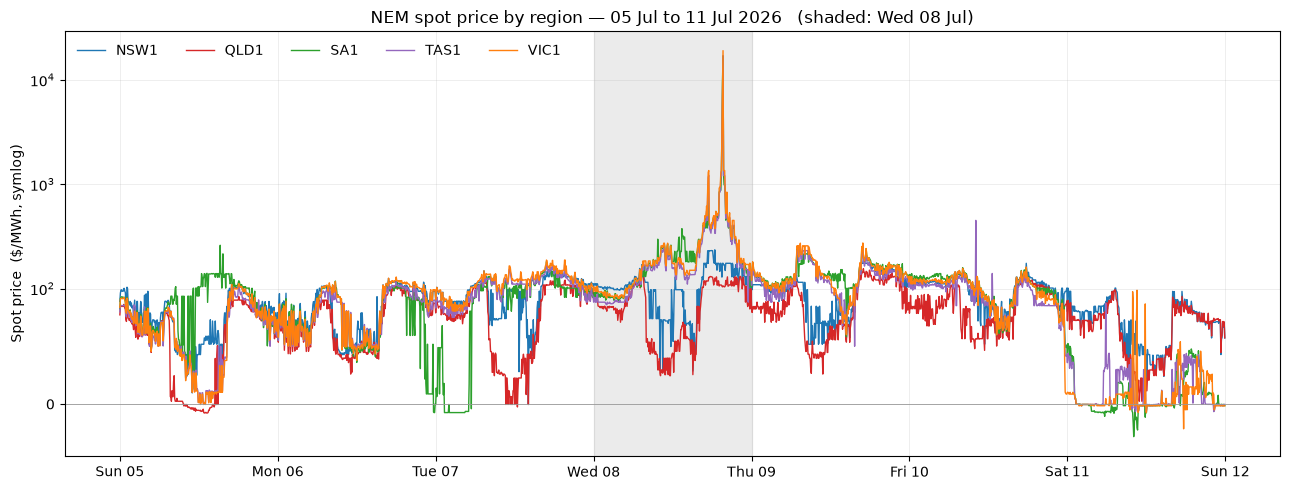

In [7]:
COLORS = {"NSW1": "#1f77b4", "QLD1": "#d62728", "SA1": "#2ca02c",
          "TAS1": "#9467bd", "VIC1": "#ff7f0e"}

fig, ax = plt.subplots(figsize=(13, 5))
for r in REGIONS:
    ax.plot(price.index, price[r], lw=1.0, color=COLORS[r], label=r)

ax.set_yscale("symlog", linthresh=100)
ax.axhline(0, color="0.6", lw=0.6)
ax.axvspan(pd.Timestamp(EVENT_DAY), pd.Timestamp(EVENT_DAY) + pd.Timedelta("1D"),
           color="0.85", alpha=0.5, zorder=0)
ax.set_ylabel("Spot price  ($/MWh, symlog)")
ax.set_title(f"NEM spot price by region — {START:%d %b} to {END - pd.Timedelta('1D'):%d %b %Y}"
             f"   (shaded: {pd.Timestamp(EVENT_DAY):%a %d %b})")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d"))
ax.legend(frameon=False, ncols=5, loc="upper left")
ax.grid(True, alpha=0.25, lw=0.6)
fig.tight_layout()

out = FIGURES / f"event_{EVENT_DAY.replace('-', '')}_week.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
print(f"saved: {out.relative_to(PROJECT_ROOT)}")

## 5. Plot — the event day

Four stacked panels sharing an x-axis, so price, load, supply mix and the supply-demand
balance can all be read against the same clock:

1. **Price** by region (symlog again).
2. **Demand** by region (operational).
3. **NEM generation by fuel**, stacked, with **both demand lines overlaid**. This is the
   whole panel: the stack is total NEM generation, and the two demand curves show why a
   naive "generation minus demand" is misleading — see §5a.
4. **Balance residual** — what's left once each demand definition is matched against the
   generation that belongs with it. Both should sit near zero.

`battery_charging` and `pumps` are loads, not supply, so they're excluded from the stack;
the `battery` band is discharge only. The dashed line marks the article's 17:15 snapshot,
the dotted line the day's highest price in any region.

saved: figures/event_20260708_day.png
dashed = article snapshot 2026-07-08 17:15 | dotted = day's price peak 2026-07-08 19:40:00


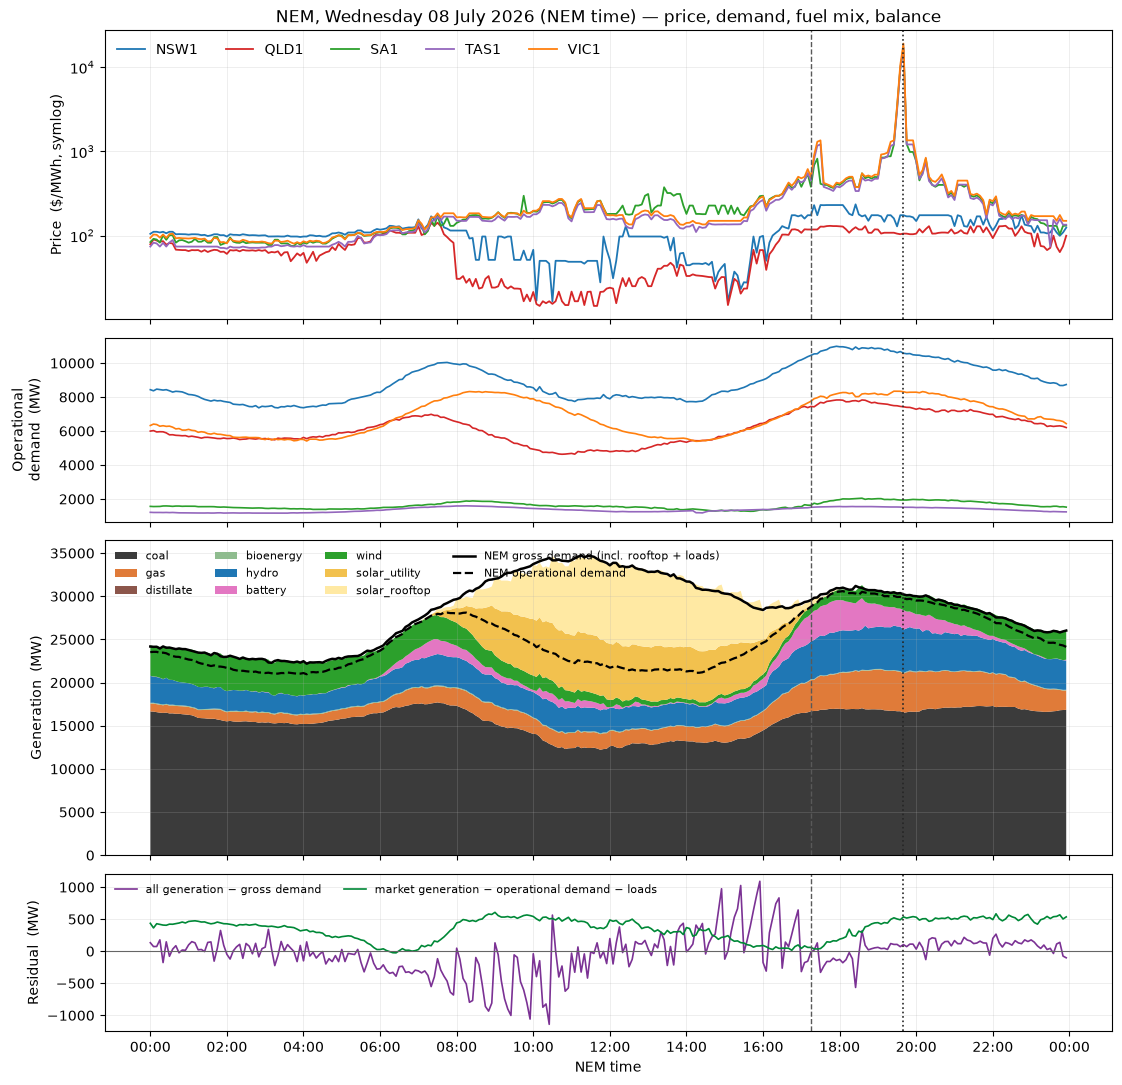

In [8]:
STACK = ["coal", "gas", "distillate", "bioenergy", "hydro",
         "battery", "wind", "solar_utility", "solar_rooftop"]
FUEL_COLORS = {"coal": "#3b3b3b", "gas": "#e07b39", "distillate": "#8c564b",
               "bioenergy": "#8fbc8f", "hydro": "#1f77b4", "battery": "#e377c2",
               "wind": "#2ca02c", "solar_utility": "#f2c14e",
               "solar_rooftop": "#ffe9a3"}

dg_day = demand_gross.loc[EVENT_DAY]
l_day = loads.loc[EVENT_DAY]
nem_gross = dg_day.sum(axis=1)

# Generation that competes in the market (everything except behind-the-meter rooftop)
mkt_gen = f_day.drop(columns=["solar_rooftop"]).sum(axis=1)
all_gen = f_day.sum(axis=1)

fig, (ax_p, ax_d, ax_g, ax_b) = plt.subplots(
    4, 1, figsize=(13, 13), sharex=True,
    gridspec_kw={"height_ratios": [2.2, 1.4, 2.4, 1.2], "hspace": 0.08},
)

for r in REGIONS:
    ax_p.plot(day.index, day[r], lw=1.3, color=COLORS[r], label=r)
ax_p.set_yscale("symlog", linthresh=100)
ax_p.set_ylabel("Price  ($/MWh, symlog)")
ax_p.set_title(f"NEM, {pd.Timestamp(EVENT_DAY):%A %d %B %Y} (NEM time) — price, demand, fuel mix, balance")
ax_p.legend(frameon=False, ncols=5, loc="upper left")

for r in REGIONS:
    ax_d.plot(d_day.index, d_day[r], lw=1.2, color=COLORS[r], label=r)
ax_d.set_ylabel("Operational\ndemand  (MW)")

stack = [c for c in STACK if c in f_day.columns]
ax_g.stackplot(f_day.index, *[f_day[c].clip(lower=0) for c in stack],
               labels=stack, colors=[FUEL_COLORS[c] for c in stack])
ax_g.plot(nem_gross.index, nem_gross, color="black", lw=1.8,
          label="NEM gross demand (incl. rooftop + loads)")
ax_g.plot(nem_demand.index, nem_demand, color="black", lw=1.6, ls="--",
          label="NEM operational demand")
ax_g.set_ylabel("Generation  (MW)")
ax_g.legend(frameon=False, ncols=4, loc="upper left", fontsize=8)

# Each demand definition against the generation that belongs with it.
ax_b.plot(f_day.index, all_gen - nem_gross, color="#7b3294", lw=1.2,
          label="all generation − gross demand")
ax_b.plot(f_day.index, mkt_gen - nem_demand - l_day, color="#008837", lw=1.2,
          label="market generation − operational demand − loads")
ax_b.axhline(0, color="0.4", lw=0.8)
ax_b.set_ylabel("Residual  (MW)")
ax_b.set_xlabel("NEM time")
ax_b.legend(frameon=False, ncols=2, loc="upper left", fontsize=8)

for ax in (ax_p, ax_d, ax_g, ax_b):
    ax.axvline(pd.Timestamp(ARTICLE_SNAPSHOT), color="0.35", ls="--", lw=1.0)
    ax.axvline(peak_t, color="0.15", ls=":", lw=1.2)
    ax.grid(True, alpha=0.25, lw=0.6)
ax_b.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax_b.xaxis.set_major_locator(mdates.HourLocator(interval=2))
# no tight_layout here: hspace is already set on the gridspec, and tight_layout
# fights the shared-x stack.

out = FIGURES / f"event_{EVENT_DAY.replace('-', '')}_day.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
print(f"saved: {out.relative_to(PROJECT_ROOT)}")
print(f"dashed = article snapshot {ARTICLE_SNAPSHOT} | dotted = day's price peak {peak_t}")

### 5a. Why the stack sits above operational demand — and what "unmet demand" would look like

The generation panel is **NEM-wide** (all five regions summed): the pull is
`get_network_data(network_code="NEM", ...)` with no regional grouping. So it is directly
comparable to the sum of the five regional demands — but only once the definitions line up.

**Two different demands.** They are not interchangeable:

- **Operational demand** (`MarketMetric.DEMAND`) — the demand met by the *market*,
  measured at the regional reference node. Rooftop solar sits behind the customer's meter,
  so it never appears as supply here; it appears as demand that simply **isn't there**.
- **Gross demand** (`MarketMetric.DEMAND_GROSS`) — operational demand with behind-the-meter
  generation and market loads (battery charging, pumping) added back: closer to what
  consumers actually consumed.

Our stack includes `solar_rooftop`, so it must be compared against **gross** demand.
Compare it against operational demand instead and you manufacture a "surplus" of several
thousand MW at midday that is nothing but rooftop solar counted on the wrong side of the
meter. That is exactly what panel 4 is there to demonstrate — both residuals hug zero,
and the leftover few hundred MW is transmission losses.

**Now the real question: how would you know demand wasn't met?**

You wouldn't see it as a gap in this chart, because **there can't be one**. AEMO's dispatch
engine solves for supply = demand in every 5-minute interval; that equality is a constraint,
not an outcome. Any residual you see here is accounting, not physics.

When supply genuinely can't cover demand, the market escalates *before* anything goes unserved:

1. **Price** rises toward the **market price cap** — that is the scarcity signal, and it is
   why the cap exists. This event is a mild version of exactly that.
2. **Lack of Reserve (LOR) notices** — LOR1, LOR2, then LOR3 as reserve margins shrink.
   These are published to the Market Notices feed. The NEMwatch screenshot in the article
   shows several, including an LOR1 forecast for the VIC region.
3. **Out-of-market intervention** — AEMO directions to generators, and the **Reliability and
   Emergency Reserve Trader (RERT)** contracting reserve that isn't bid into the market.
4. **Involuntary load shedding** — only if all of the above fall short. AEMO directs the
   transmission and distribution businesses to disconnect blocks of customers, chosen by
   the distributor under state rotational schedules with protected loads exempt.

So "which demand wasn't met" is never a residual you compute — it is **load shedding, and
it shows up as demand dropping**, plus a matching trail of LOR3 and direction notices.
After the fact, AEMO reports it as **Unserved Energy (USE)** against the reliability
standard. None of those appear in a price/demand/generation pull; they live in the market
notices and PASA reserve tables (`PDPASA` / `STPASA` / `MTPASA`), which is the pull to add
if you ever want to model reliability rather than price.

For a dispatch model this is a useful simplification: you never model unserved load. You
model price, and let the cap represent scarcity.

## 6. Your read — what happened, and what drove it?  _(owner writes this)_

The seed of `nem-field-notes.md` (curriculum Phase 1). Two or three sentences in your own
words is enough today. CLAUDE.md keeps this section owner-only: what a price event means
and what caused it is the judgement the artifact is evidence of.

- **What is the event?** Where does it sit in the 5-minute trace, which regions, how long?
  Note the article was written at 17:15 — does the data agree that's when the action was? …

- **Best guess at the driver.** The article offers demand peak, sunset solar, low wind,
  the VIC1–NSW1 constraint, Loy Yang A/B. Which does §3a actually support, and which
  can't you tell from this data alone? …

- **Why the three southern regions and not NSW1/QLD1?** …

- **What would a battery have done?** This is the one that matters for the project —
  where would you have wanted charge, and what does the event imply about how much of a
  year's arbitrage revenue lands in a handful of intervals? …

- **Data traps noticed?** (gaps, nulls, negative prices, intervention intervals) …